# Email Spam Detection

## Step 1 — Import Libraries and Dataset

In this step, we load the dataset and inspect its basic structure.

In [186]:
import pandas as pd

df = pd.read_csv('/home/ahmed/.cache/kagglehub/datasets/jackksoncsie/spam-email-dataset/versions/1/emails.csv')

df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [187]:
import pandas as pd

df = pd.read_csv('/home/ahmed/.cache/kagglehub/datasets/jackksoncsie/spam-email-dataset/versions/1/emails.csv')

df.columns

Index(['text', 'spam'], dtype='str')

In [188]:
df.shape

(5728, 2)

In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [190]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [191]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

# Step 2 — Data Cleaning

In [192]:
df.shape

(5728, 2)

In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [194]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [195]:
df.duplicated().sum()

np.int64(33)

In [196]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [197]:
df = df.dropna(subset=["text", "spam"])

In [198]:
df.duplicated().sum()

np.int64(33)

In [199]:
df[df.duplicated()].head()

,text,spam
2155,Subject: research allocations to egm hi becky...,0
2260,Subject: departure of grant masson the resear...,0
2412,"Subject: re : schedule and more . . jinbaek ,...",0
2473,"Subject: day off tuesday stinson , i would l...",0
2763,"Subject: re : your mail zhendong , dr . kami...",0


In [200]:
df = df.drop_duplicates()

In [201]:
df.duplicated().sum()

np.int64(0)

In [202]:
(df["text"].astype(str).str.strip() == "").sum()

np.int64(0)

In [203]:
df = df[df["text"].astype(str).str.strip() != ""]

In [204]:
df["spam"].unique()

array([1, 0])

In [205]:
df["spam"].value_counts(dropna=False)

spam
0    4327
1    1368
Name: count, dtype: int64

In [206]:
df["text"].dtype

<StringDtype(storage='python', na_value=nan)>

In [207]:
df["text"].head()

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: str

In [208]:
(df["text"].astype(str).str.len()).describe()

count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text, dtype: float64

In [209]:
df = df.dropna(subset=["text", "spam"])

In [210]:
df = df.drop_duplicates()

In [211]:
df = df[df["text"].astype(str).str.strip() != ""]

In [212]:
print("Shape: ", df.shape)

Shape:  (5695, 2)


In [213]:
print("\nMissing values: ")
print(df.isnull().sum())


Missing values: 
text    0
spam    0
dtype: int64


In [214]:
print("\nDuplicates: ")
print(df.duplicated().sum())


Duplicates: 
0


In [215]:
print("\nLabels:")
print(df.value_counts(dropna=False))


Labels:
text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [216]:
print("\nEmail lengths:")
print(df['text'].astype(str).str.len().describe())


Email lengths:
count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text, dtype: float64


In [217]:
df["spam"].value_counts(dropna=False)

spam
0    4327
1    1368
Name: count, dtype: int64

## Step 3 — Distribution of Labels

In [218]:
label_counts = df.value_counts()
print(label_counts)

text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [219]:
label_percentages = (df["spam"].value_counts(normalize=True)) * 100
print(label_percentages)

spam
0    75.978929
1    24.021071
Name: proportion, dtype: float64


In [220]:
label_names = df['spam'].map({
    0: "Ham",
    1: "Spam"
})

label_names.head()

0    Spam
1    Spam
2    Spam
3    Spam
4    Spam
Name: spam, dtype: str

/tmp/ipykernel_102984/3032231013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=label_names, order = ["Ham", "Spam"], palette={"Ham": "#4CAF50", "Spam": "#FF5722"},)


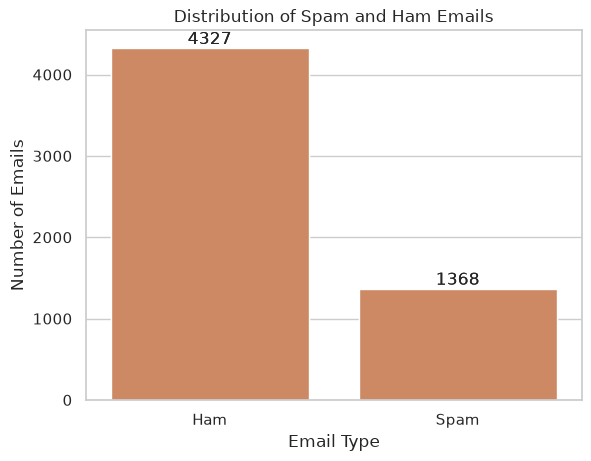

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.countplot(x=label_names, order = ["Ham", "Spam"], palette={"Ham": "#4CAF50", "Spam": "#FF5722"},)
ax = sns.countplot(x = label_names)
plt.title("Distribution of Spam and Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()


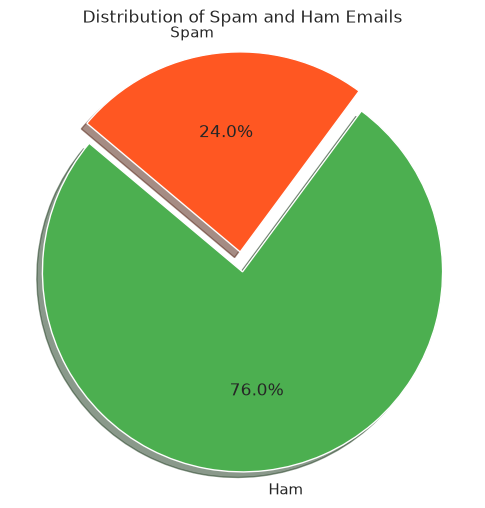

In [222]:
class_counts = df['spam'].value_counts()
labels = ['Ham', 'Spam']
sizes = [class_counts[0], class_counts[1]] 
colors = ['#4CAF50', '#FF5722']
explode = (0, 0.1)
plt.figure(figsize=(6, 6))

plt.pie(
    sizes, 
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140
)

plt.title("Distribution of Spam and Ham Emails")
plt.axis('equal')
plt.show()

In [223]:
df["text_length"] = df["text"].str.len()

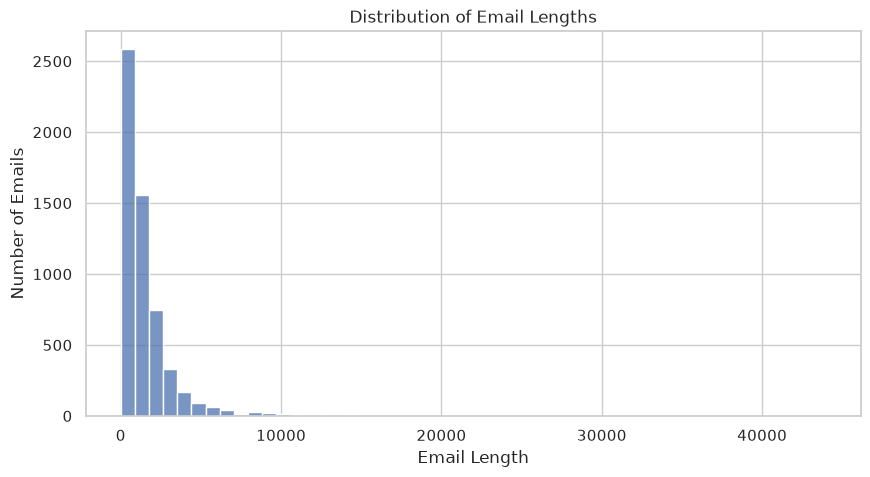

In [224]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x= "text_length",
    bins = 50
)

plt.title("Distribution of Email Lengths")
plt.xlabel("Email Length")
plt.ylabel("Number of Emails")
plt.show()

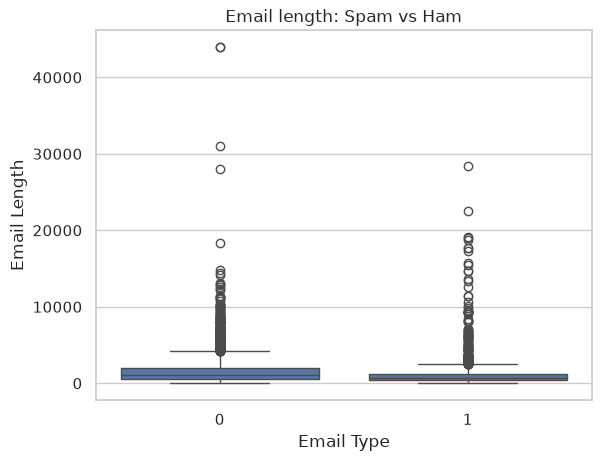

In [225]:
sns.boxplot(
    data= df,
    x="spam",
    y="text_length"
)

plt.title("Email length: Spam vs Ham")
plt.xlabel("Email Type")
plt.ylabel("Email Length")

plt.show()

## Step 4 — Preprocessing: Cleaning the Junk

In [226]:
df['text'].head(10)

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
5    Subject: great nnews  hello , welcome to medzo...
6    Subject: here ' s a hot play in motion  homela...
7    Subject: save your money buy getting this thin...
8    Subject: undeliverable : home based business f...
9    Subject: save your money buy getting this thin...
Name: text, dtype: str

In [227]:
df[df['spam'] == 1]['text'].head(5)

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: str

In [228]:
df[df['spam'] == 0]['text'].head(5)

1368    Subject: hello guys ,  i ' m " bugging you " f...
1369    Subject: sacramento weather station  fyi  - - ...
1370    Subject: from the enron india newsdesk - jan 1...
1371    Subject: re : powerisk 2001 - your invitation ...
1372    Subject: re : resco database and customer capt...
Name: text, dtype: str

In [229]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [230]:
sample = """
CONGRATULATIONS!!! <b>You WON $500!</b>
Visit https://example.com/claim NOW!!!
"""

print(clean_text(sample))

congratulations you won 500 visit now


In [231]:
for i in range(5):
    print("="*80)
    sample_email = df['text'].iloc[i]
    print("\nOriginal text:")
    print(sample_email)

    print("\nCleaned text:")
    print(clean_text(sample_email))


Original text:
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordabi

In [232]:
df['clean_text'] = df["text"].apply(clean_text)

In [233]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: naturally irresistible your corporate...,subject naturally irresistible your corporate ...
1,Subject: the stock trading gunslinger fanny i...,subject the stock trading gunslinger fanny is ...
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new homes made easy im wa...
3,Subject: 4 color printing special request add...,subject 4 color printing special request addit...
4,"Subject: do not have money , get software cds ...",subject do not have money get software cds fro...


In [234]:
(df['clean_text'].astype(str).str.strip() != "").sum()

np.int64(5695)

In [235]:
df[['text', 'clean_text', 'spam']].head(10)

,text,clean_text,spam
0,Subject: naturally irresistible your corporate...,subject naturally irresistible your corporate ...,1
1,Subject: the stock trading gunslinger fanny i...,subject the stock trading gunslinger fanny is ...,1
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new homes made easy im wa...,1
3,Subject: 4 color printing special request add...,subject 4 color printing special request addit...,1
4,"Subject: do not have money , get software cds ...",subject do not have money get software cds fro...,1
5,"Subject: great nnews hello , welcome to medzo...",subject great nnews hello welcome to medzonlin...,1
6,Subject: here ' s a hot play in motion homela...,subject here s a hot play in motion homeland s...,1
7,Subject: save your money buy getting this thin...,subject save your money buy getting this thing...,1
8,Subject: undeliverable : home based business f...,subject undeliverable home based business for ...,1
9,Subject: save your money buy getting this thin...,subject save your money buy getting this thing...,1


In [236]:
df["clean_text"].str.len().describe()

count     5695.000000
mean      1359.122388
std       1832.552661
min         11.000000
25%        448.000000
50%        854.000000
75%       1629.000000
max      41279.000000
Name: clean_text, dtype: float64

In [237]:
df['text'].str.len().describe()

count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text, dtype: float64

In [240]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [242]:
from src.preprocessing.cleaning import clean_text

df["clean_text"] = df["text"].apply(clean_text)